# Exploration du dataset UE
Seuls les véhicules de l'année 2023 et de la France ont été exportés à partir de https://www.eea.europa.eu/data-and-maps/data/co2-cars-emission-20

# <font color='#3585CD'>Importation des librairies</font>


In [153]:
import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go

# <font color='#3585CD'>Chargement des données</font>

## Chargement du dataset principal


In [154]:
# chemin vers le dataset
dataset_path = "data.csv"
df = pd.read_csv(dataset_path)
df.head(10)

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,122083623,FR,IP-YHT____MB6_5123-VR3-0,STELLANTIS,STELLANTIS AUTO,STELLANTIS AUTO SAS,NaN,E2*2007/46*0639*20,U,B,...,1.87,NaN,NaN,F,2023,2023-01-24,4.1,Euro 6 AP,NaN,NaN
1,122083624,FR,IP-0001137-WBA,BMW,BMW AG,BAYERISCHE MOTOREN WERKE AG,NaN,E1*2018/858*00153*04,U1X,71EG,...,NaN,NaN,NaN,F,2023,2023-12-28,NaN,AX,NaN,455.0
2,122083625,FR,IP-MQB37SZ_A3_1035-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E13*2007/46*1845*27,A1,DXDBX0AC4,...,1.17,NaN,NaN,F,2023,2023-06-30,6.2,Euro 6 AP,NaN,NaN
3,122083626,FR,IP-JBA1N1PDW5A_001-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,E2*2007/46*0684*21,RJB,HH2,...,2.11,NaN,NaN,F,2023,2023-03-27,6.0,6AP,NaN,NaN
4,122083627,FR,IP-MQB27ZZ_A1_0533-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*1783*38,AW,ABDLAC,...,1.14,NaN,NaN,F,2023,2023-10-11,5.5,Euro 6 AP,NaN,NaN
5,122083628,FR,IP-6_00459-TSM-1,SUBARU-SUZUKI-TOYOTA,MAGYAR SUZUKI,MAGYAR SUZUKI CORPORATION LTD,NaN,E4*2007/46*0928*13,LY,DH1S,...,0.78,NaN,NaN,F,2023,2023-09-28,5.3,N.A.,N.A.,NaN
6,122083629,FR,IP-HNE____MB6D542F-VR3-0,STELLANTIS,STELLANTIS AUTO,STELLANTIS AUTO SAS,NaN,E2*2007/46*0639*23,U,P,...,2.12,NaN,NaN,F,2023,2023-04-28,5.1,Euro 6 AP,NaN,NaN
7,122083630,FR,IP-JLA1MUP001A_001-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,E6*2018/858*00003*12,RJL,LH2,...,0.89,NaN,NaN,F,2023,2023-10-13,4.7,6AP,NaN,NaN
8,122083631,FR,IP-MEB31_Z_A0_1912-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2033*13,E1,ACEBJCL1FX2,...,NaN,NaN,NaN,F,2023,2023-06-09,NaN,AX,NaN,426.0
9,122083632,FR,IP-MEB31AZ_A0_1911-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,NaN,E8*2007/46*0416*12,NY,ABEBJCL1LX2,...,NaN,NaN,NaN,F,2023,2023-12-28,NaN,NaN,NaN,397.0


In [155]:
# Suppression des espaces accidentels dans les noms des colonnes comme "Fuel consumption "
df.columns = df.columns.str.strip()

## Chargement du dataset du dictionnaire des variables

In [156]:
pd.set_option('display.max_colwidth', None) # pour pouvoir afficher tout le descriptif
dataset_variables = "Table-definition.xlsx"
var = pd.read_excel(dataset_variables)
var.head(40)

,Nom de la variable,Descriptif,Type
0,ID,Identifiant,int64
1,Country,Pays,object
2,VFN,Numéro d'identification de la famille du véhicule.,object
3,Mp,Pool des constructeurs,object
4,Mh,Nom du fabricant Dénomination standard de l'UE.,object
5,Man,Déclaration OEM du nom du fabricant.,object
6,MMS,Nom du fabricant Dénomination du registre MS.,float64
7,Tan,Numéro d'homologation de type.,object
8,T,Type,object
9,Va,Variante,object


# <font color='#3585CD'>Premières analyses</font>


## Informations sur le dataset

In [157]:
print("\nAperçu du dataset :")
print(df.info())


Aperçu du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1889602 entries, 0 to 1889601
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          int64  
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)             

## Satistiques descriptives

In [158]:
print("\nStatistiques descriptives :")
display(df.describe(include='all').T)


Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1889602.0,NaN,NaN,NaN,121995167.323494,566723.083392,2281.0,121522959.25,121995359.5,122467759.75,122940160.0
Country,1889602,1,FR,1889602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VFN,1889599,2480,IP-JAA1MTPJT4A_000-VF1-1,47701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mp,1756549,11,STELLANTIS,526951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mh,1889602,81,RENAULT,342747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Man,1889602,79,RENAULT SAS,342802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MMS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tan,1889601,1803,E2*2007/46*0639*23,44324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
T,1889601,403,U,195548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Va,1889601,1775,BE2,103745,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
# Calculer le nombre de valeurs uniques par colonne et renommer la colonne
df_unique_values = df.nunique().sort_values(ascending=False).reset_index()
df_unique_values.columns = ["colonne", "nombre de valeurs uniques"]

df_unique_values

,colonne,nombre de valeurs uniques
0,ID,1889602
1,Ve,6651
2,VFN,2480
3,Mt,2032
4,Tan,1803
5,Va,1775
6,m (kg),1147
7,Cn,963
8,Electric range (km),563
9,T,403


## Analyse rapide des colonnes
<p>La fonction analyse_columns permet de visualiser les différentes colonnes avec un échantillon de valeurs</p>

In [160]:

def analyse_columns(df):
  """
  Analyse les colonnes d'un DataFrame : nom, type, nombre de valeurs uniques et exemples de valeurs.

  :param df: DataFrame Pandas
  :return: DataFrame avec l'analyse des colonnes
  """
  analysis = []

  for col in df.columns:
      col_name = col
      col_type = df[col].dtype
      unique_count = df[col].nunique()  # Nombre de valeurs uniques
      unique_values = df[col].dropna().unique()[:5].tolist()  # Exemples (max 5)

      analysis.append({
          'Nom de la colonne': col_name,
          'Type de la colonne': col_type,
          'Nombre de valeurs uniques': unique_count,
          'Exemples de valeurs': unique_values
      })

  return pd.DataFrame(analysis)

In [161]:
analysis_df = analyse_columns(df)
analysis_df

,Nom de la colonne,Type de la colonne,Nombre de valeurs uniques,Exemples de valeurs
0,ID,int64,1889602,"[122083623, 122083624, 122083625, 122083626, 122083627]"
1,Country,object,1,[FR]
2,VFN,object,2480,"[IP-YHT____MB6_5123-VR3-0, IP-0001137-WBA, IP-MQB37SZ_A3_1035-WVW-1, IP-JBA1N1PDW5A_001-VF1-1, IP-MQB27ZZ_A1_0533-WVW-1]"
3,Mp,object,11,"[STELLANTIS, BMW, VOLKSWAGEN, RENAULT-NISSAN-MITSUBISHI, SUBARU-SUZUKI-TOYOTA]"
4,Mh,object,81,"[STELLANTIS AUTO, BMW AG, VOLKSWAGEN, RENAULT, MAGYAR SUZUKI]"
5,Man,object,79,"[STELLANTIS AUTO SAS, BAYERISCHE MOTOREN WERKE AG, VOLKSWAGEN AG, RENAULT SAS, MAGYAR SUZUKI CORPORATION LTD]"
6,MMS,float64,0,[]
7,Tan,object,1803,"[E2*2007/46*0639*20, E1*2018/858*00153*04, E13*2007/46*1845*27, E2*2007/46*0684*21, E1*2007/46*1783*38]"
8,T,object,403,"[U, U1X, A1, RJB, AW]"
9,Va,object,1775,"[B, 71EG, DXDBX0AC4, HH2, ABDLAC]"


# <font color='#3585CD'>Analyse des valeurs manquantes</font>


In [162]:

def display_missing_values(df):
  """
  Affiche un DataFrame contenant les valeurs manquantes, leur pourcentage / nombre et leur type, pour chaque colonne du DataFrame.

  :param df: DataFrame contenant la variable à analyser.
  """
  missing_values = df.isnull().sum()
  missing_ratio = (missing_values / len(df)) * 100

  missing_values_df = pd.DataFrame({
      'Colonne': missing_values.index,
      'Valeurs manquantes (%)': missing_ratio.values,
      'Nombre de valeurs manquantes': missing_values.values,
      'Type': df.dtypes.values
  })

  missing_values_df = missing_values_df[missing_values_df['Nombre de valeurs manquantes'] > 0]
  missing_values_df = missing_values_df.sort_values(by='Valeurs manquantes (%)', ascending=False).reset_index(drop=True)

  return missing_values_df


In [163]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,At2 (mm),100.000000,1889602,float64
1,W (mm),100.000000,1889602,float64
2,MMS,100.000000,1889602,float64
3,Vf,100.000000,1889602,float64
4,De,100.000000,1889602,float64
5,Ernedc (g/km),100.000000,1889602,float64
6,At1 (mm),100.000000,1889602,float64
7,Enedc (g/km),100.000000,1889602,float64
8,RLFI,96.669563,1826670,object
9,z (Wh/km),74.900852,1415328,float64


In [164]:
# Afficher le nombre de doublons par colonne
for column in df.columns:
    duplicates_count = df[column].duplicated().sum()  # Compter le nombre de doublons pour chaque colonne
    if duplicates_count > 0:
        print(f"La colonne '{column}' a  : {duplicates_count}")
    else:
        print(f"La colonne '{column}' n'a pas de doublons.")

La colonne 'ID' n'a pas de doublons.
La colonne 'Country' a  : 1889601
La colonne 'VFN' a  : 1887121
La colonne 'Mp' a  : 1889590
La colonne 'Mh' a  : 1889521
La colonne 'Man' a  : 1889523
La colonne 'MMS' a  : 1889601
La colonne 'Tan' a  : 1887798
La colonne 'T' a  : 1889198
La colonne 'Va' a  : 1887826
La colonne 'Ve' a  : 1882950
La colonne 'Mk' a  : 1889525
La colonne 'Cn' a  : 1888639
La colonne 'Ct' a  : 1889600
La colonne 'Cr' a  : 1889600
La colonne 'r' a  : 1889601
La colonne 'm (kg)' a  : 1888454
La colonne 'Mt' a  : 1887569
La colonne 'Enedc (g/km)' a  : 1889601
La colonne 'Ewltp (g/km)' a  : 1889268
La colonne 'W (mm)' a  : 1889601
La colonne 'At1 (mm)' a  : 1889601
La colonne 'At2 (mm)' a  : 1889601
La colonne 'Ft' a  : 1889593
La colonne 'Fm' a  : 1889596
La colonne 'ec (cm3)' a  : 1889505
La colonne 'ep (KW)' a  : 1889368
La colonne 'z (Wh/km)' a  : 1889391
La colonne 'IT' a  : 1889514
La colonne 'Ernedc (g/km)' a  : 1889601
La colonne 'Erwltp (g/km)' a  : 1889427
La col

In [165]:
# suppression des doublons en actualisant l'index
df = df.drop_duplicates().reset_index(drop=True)

In [166]:
print(df.duplicated().sum())

0


# <font color='#3585CD'>Suppression de colonnes</font>

Nous pouvons dès à présent ces colonnes qui ont un taux de valeurs manquantes supérieur à 70% :

*   At2 (mm)
*   W (mm)
*   MMS
*   Vf
*   De
*   Ernedc (g/km)
*   At1 (mm)
*   Enedc (g/km)
*   RLFI
*   z (Wh/km)
*   Electric range (km)

In [167]:
df = df.drop(columns=['At2 (mm)',	'W (mm)',	'MMS',	'Vf',	'De', 'Ernedc (g/km)',	'At1 (mm)',	'Enedc (g/km)',	'RLFI',	'z (Wh/km)', 'Electric range (km)'], axis=1)

In [168]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,IT,30.613695,578477,object
1,Erwltp (g/km),30.613695,578477,float64
2,Fuel consumption,16.391547,309735,float64
3,ec (cm3),16.391494,309734,float64
4,Mp,7.041324,133053,object
5,ech,5.168125,97657,object
6,ep (KW),0.171412,3239,float64
7,VFN,0.000159,3,object
8,Ve,0.000106,2,object
9,Tan,0.000053,1,object


# <font color='#3585CD'>Suppresion des colonnes non pertinentes</font>

Certaines colonnes n'ont pas d'intérêt à être gardées :

*   IT <strong> * (gardé pour l'instant)</strong>
*   Erwltp (g/km) (dépreciée) <strong>* (gardé pour l'instant)</strong>
*   ID : identifiant du véhicule (indexée)
*   Country : notre dataset est une extraction des véhicules de France
*   VFN : n'a pas de norme universelle et comporte trop de valeurs
*   Tan : trop de valeurs et sans intérêt pour notre projet
*   T : trop de valeurs et sans intérêt pour notre projet
*   Va : trop de valeurs et sans intérêt pour notre projet
*   Ve : trop de valeurs et sans intérêt pour notre projet
*   Status : n'a qu'une seule valeur et ne varie pas
*   Year : 1 seule valeur
*   Date of registration : sans intérêt pour notre projet     <strong> *(gardé pour l'instant)</strong>
*   Fm : redondant avec Ft
*   Cr : nous avons 2 catégories (M1, M1G). M1G est une sous-catégorie de M1 réservée aux véhicules tout-terrain. Nous pouvons conclure que tous les véhicules sont de catégorie M1
*   Ct : idem que Cr
*   ech : sans intérêt pour notre projet
*   Mp : redondant, se retrouve dans une autre colonne
*   Man : redondant avec Mk
*   r : n'a qu'une seule valeur
*   Mh : redondant avec Mk


In [169]:
df = df.drop(columns=['Country', 'VFN', 'Tan', 'T', 'Va', 'Ve', 'Status', 'year', 'Fm', 'Cr', 'Ct', 'ech', 'Mp', 'Man', 'r', 'Mh'], axis=1)

 # <font color='#3585CD'>Affichage du pourcentage de valeurs manquantes par colonne</font>


In [170]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]  # Filtrer les colonnes avec NaN
print(missing_percentage)

m (kg)               0.000053
Mt                   0.000053
ec (cm3)            16.391494
ep (KW)              0.171412
IT                  30.613695
Erwltp (g/km)       30.613695
Fuel consumption    16.391547
dtype: float64


In [171]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,IT,30.613695,578477,object
1,Erwltp (g/km),30.613695,578477,float64
2,Fuel consumption,16.391547,309735,float64
3,ec (cm3),16.391494,309734,float64
4,ep (KW),0.171412,3239,float64
5,m (kg),0.000053,1,float64
6,Mt,0.000053,1,float64


In [172]:
print(f"Nombre total de lignes : {df.shape[0]}")

Nombre total de lignes : 1889602


In [173]:
df = df.dropna(subset=["Fuel consumption"])

In [174]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,IT,17.010419,268742,object
1,Erwltp (g/km),17.010419,268742,float64


In [175]:
print(f"Nombre total de lignes : {df.shape[0]}")

Nombre total de lignes : 1579867


In [176]:
df.columns

Index(['ID', 'Mk', 'Cn', 'm (kg)', 'Mt', 'Ewltp (g/km)', 'Ft', 'ec (cm3)',
       'ep (KW)', 'IT', 'Erwltp (g/km)', 'Date of registration',
       'Fuel consumption'],
      dtype='object')

# Vérification de la corrélation entre la colonne IT (catégorielle) et les émissions de CO2

In [177]:
from sklearn.preprocessing import LabelEncoder

# Initialiser l'encodeur
encoder = LabelEncoder()

# Encoder la colonne IT
df['IT_encoded'] = encoder.fit_transform(df['IT'])

# Calculer la corrélation entre la colonne encodée IT et CO2
correlation_IT_CO2 = df[['IT_encoded', 'Erwltp (g/km)', 'Ewltp (g/km)']].corr()

print(correlation_IT_CO2)

               IT_encoded  Erwltp (g/km)  Ewltp (g/km)
IT_encoded       1.000000      -0.079299     -0.484160
Erwltp (g/km)   -0.079299       1.000000      0.276758
Ewltp (g/km)    -0.484160       0.276758      1.000000


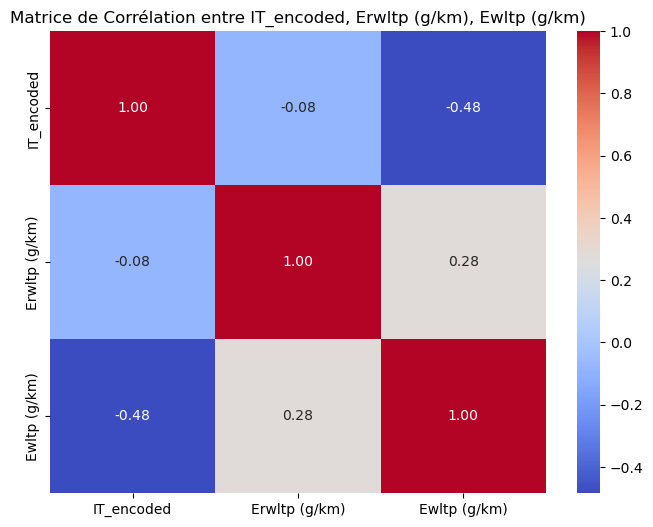

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de corrélation
corr_matrix = df[['IT_encoded', 'Erwltp (g/km)', 'Ewltp (g/km)']].corr()

# Affichage du heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation entre IT_encoded, Erwltp (g/km), Ewltp (g/km)')
plt.show()

<strong> IT_encoded et Emission CO2:</strong> Une corrélation négative modérée (-0.48) suggère que les véhicules avec des technologies innovantes (IT) ont tendance à émettre moins de CO2.

<strong>Reduction emission CO2 et Emission CO2 :</strong> Avec une corrélation de 0,28, on observe une légère relation positive entre l'impact de l'innovation et les émissions de CO2. Cela suggère que les technologies innovantes pourraient avoir une certaine influence, mais leur effet reste relativement modéré.

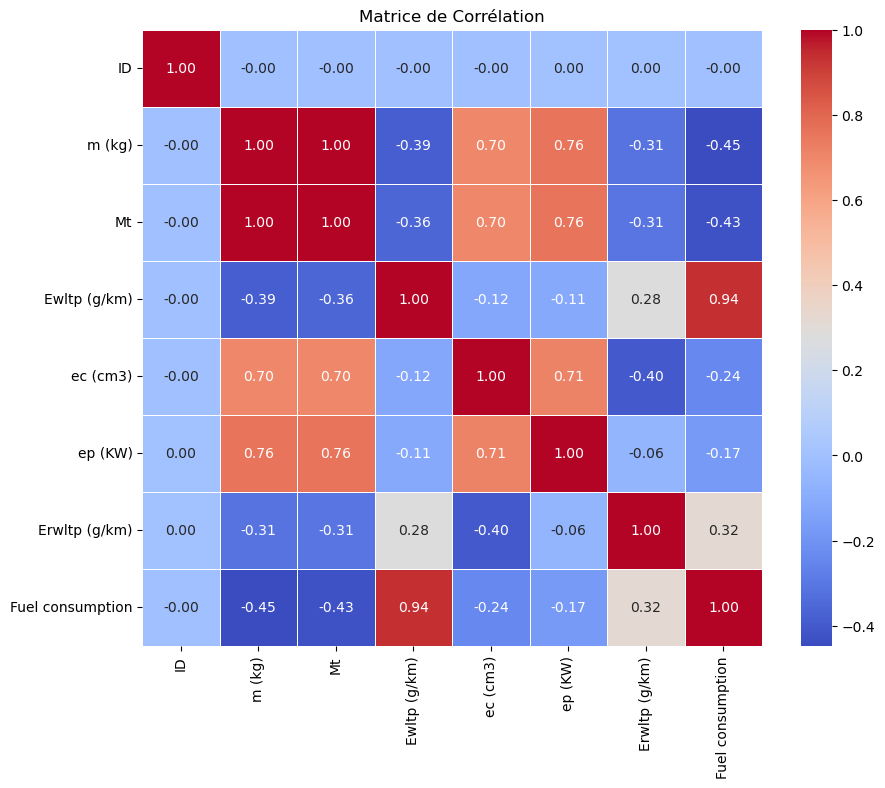

In [179]:
# Sélectionner uniquement les colonnes numériques
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculer la matrice de corrélation uniquement sur les colonnes numériques
correlation_matrix = numeric_df.corr()

# Afficher la matrice de corrélation
import seaborn as sns
import matplotlib.pyplot as plt

# Tracer la heatmap de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

## <strong> Gestion de valeurs manquantes restantes

In [180]:
df = df.dropna(subset=["IT"])

In [181]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type


# <font color='#3585CD'>Renommage des colonnes</font>

Pour plus de compréhension, nous allons renommer les colonnes :

*   ID: Identifiant
*   Mk : Marque
*   Cn : Modele
*   Mt : Masse
*   Ewltp (g/km) : Co2
*   Ft : Carburant
*   ec (cm3) : Cylindree moteur
*   ep (KW) : Puissance moteur
*   IT : Techno
*   Date of registration: dt_enreg
*   Erwltp (g/km): Reduction emission CO2
*   Fuel consumption : Consommation carburant

In [182]:
renommage = {
    'IT': 'type_innovation',
    'Erwltp (g/km)': 'impact_innovaion',
    'Mk': 'Marque',
    'Cn': 'Modèle',
    'm (kg)' : 'Masse à vide',
    'Mt': 'Masse totale',
    'Ewltp (g/km)': 'CO2',
    'Ft': 'Carburant',
    'ec (cm3)': 'Cylindrée moteur',
    'ep (KW)': 'Puissance moteur',
    'Fuel consumption': 'Consommation carburant',
    'Date of registration': 'Date_enregistrement',
    'IT_encoded':'type_innovation_encod'
}

# Application du renommage
df.rename(columns=renommage, inplace=True)

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1311125 entries, 0 to 1889600
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   ID                      1311125 non-null  int64  
 1   Marque                  1311125 non-null  object 
 2   Modèle                  1311125 non-null  object 
 3   Masse à vide            1311125 non-null  float64
 4   Masse totale            1311125 non-null  float64
 5   CO2                     1311125 non-null  int64  
 6   Carburant               1311125 non-null  object 
 7   Cylindrée moteur        1311125 non-null  float64
 8   Puissance moteur        1311125 non-null  float64
 9   type_innovation         1311125 non-null  object 
 10  impact_innovaion        1311125 non-null  float64
 11  Date_enregistrement     1311125 non-null  object 
 12  Consommation carburant  1311125 non-null  float64
 13  type_innovation_encod   1311125 non-null  int32  
dtypes:

In [264]:
#Sauvegarde
#df1=df
df=df1
df1.shape

(1311125, 14)

# <font color='#3585CD'>Valeurs aberrantes</font>

Masse à vide

In [265]:
print("La valeur minimale est : ", df['Masse à vide'].min())
print("La valeur maximale est : ", df['Masse à vide'].max())
print("La valeur médiane est : ", df['Masse à vide'].median(), '\n')

q1, q2, q3 = df['Masse à vide'].quantile(q=[0.25, 0.5, 0.75])

print("Les quartiles sont:", "q1 =", q1, ", q2 =", q2, ", q3 =", q3, '\n')

etendue = q3-q1
seuil_min = q1 - 1.5*etendue
seuil_max = q3 + 1.5*etendue

print("Les valeurs extrêmes sont toutes les valeurs inférieures à", seuil_min ,
      "et toutes les valeurs supérieures à", seuil_max)

df=df[(df['Masse à vide'] >= seuil_min) & (df['Masse à vide'] <= seuil_max)]

La valeur minimale est :  -1.9742317784391028
La valeur maximale est :  6.97728995424366
La valeur médiane est :  -0.11646102015431305 

Les quartiles sont: q1 = -0.8204583601359176 , q2 = -0.11646102015431305 , q3 = 0.6266472831596028 

Les valeurs extrêmes sont toutes les valeurs inférieures à -2.991116825079198 et toutes les valeurs supérieures à 2.7973057481028833


Cylindree moteur

In [266]:
print("La valeur minimale est : ", df['Cylindrée moteur'].min())
print("La valeur maximale est : ", df['Cylindrée moteur'].max())
print("La valeur médiane est : ", df['Cylindrée moteur'].median(), '\n')

q1, q2, q3 = df['Cylindrée moteur'].quantile(q=[0.25, 0.5, 0.75])

print("Les quartiles sont:", "q1 =", q1, ", q2 =", q2, ", q3 =", q3, '\n')

etendue = q3-q1
seuil_min = q1 - 1.5*etendue
seuil_max = q3 + 1.5*etendue

print("Les valeurs extrêmes sont toutes les valeurs inférieures à", seuil_min ,
      "et toutes les valeurs supérieures à", seuil_max)

df=df[(df['Cylindrée moteur'] >= seuil_min) & (df['Cylindrée moteur'] <= seuil_max)]


La valeur minimale est :  -1.374043212690372
La valeur maximale est :  10.975345916020233
La valeur médiane est :  -0.4129089158606254 

Les quartiles sont: q1 = -1.0062016916814567 , q2 = -0.4129089158606254 , q3 = 0.47703024787062165 

Les valeurs extrêmes sont toutes les valeurs inférieures à -3.231049601009574 et toutes les valeurs supérieures à 2.701878157198739


Puissance moteur

In [267]:
print("La valeur minimale est : ", df['Puissance moteur'].min())
print("La valeur maximale est : ", df['Puissance moteur'].max())
print("La valeur médiane est : ", df['Puissance moteur'].median(), '\n')

q1, q2, q3 = df['Puissance moteur'].quantile(q=[0.25, 0.5, 0.75])

print("Les quartiles sont:", "q1 =", q1, ", q2 =", q2, ", q3 =", q3, '\n')

etendue = q3-q1
seuil_min = q1 - 1.5*etendue
seuil_max = q3 + 1.5*etendue

print("Les valeurs extrêmes sont toutes les valeurs inférieures à", seuil_min ,
      "et toutes les valeurs supérieures à", seuil_max)


df=df[(df['Puissance moteur'] >= seuil_min) & (df['Puissance moteur'] <= seuil_max)]


La valeur minimale est :  -1.4672074892679545
La valeur maximale est :  6.16652856966017
La valeur médiane est :  -0.1884598245744108 

Les quartiles sont: q1 = -0.6922089046052008 , q2 = -0.1884598245744108 , q3 = 0.39278911392265453 

Les valeurs extrêmes sont toutes les valeurs inférieures à -2.319705932396984 et toutes les valeurs supérieures à 2.0202861417144375


In [268]:
df.shape

(1257170, 14)

# <font color='#3585CD'>Normalisation</font>

In [269]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()

df['Puissance moteur'] = scaler.fit_transform(df[['Puissance moteur']])
df['Cylindrée moteur'] = scaler.fit_transform(df[['Cylindrée moteur']])
df['Masse à vide'] = scaler.fit_transform(df[['Masse à vide']])

df

,ID,Marque,Modèle,Masse à vide,Masse totale,CO2,Carburant,Cylindrée moteur,Puissance moteur,type_innovation,impact_innovaion,Date_enregistrement,Consommation carburant,type_innovation_encod
0,122083623,PEUGEOT,208,-0.864489,1282.0,107,diesel,0.702896,-0.419143,e2 28 29,1.87,2023-01-24,4.1,20
2,122083625,VOLKSWAGEN,T-ROC,0.208428,1487.0,139,petrol,0.699326,1.425914,e13 29,1.17,2023-06-30,6.2,11
3,122083626,RENAULT,CAPTUR,0.291816,1477.0,136,petrol,0.106755,1.742210,e2 33 37,2.11,2023-03-27,6.0,26
4,122083627,VOLKSWAGEN,POLO,-0.692155,1321.0,126,petrol,-1.081956,-0.682723,e1 29,1.14,2023-10-11,5.5,5
5,122083628,SUZUKI,VITARA,-0.002820,1418.0,119,petrol,0.570817,-0.419143,e6 37,0.78,2023-09-28,5.3,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889595,121999993,HYUNDAI,TUCSON IX35,1.770552,1802.0,131,petrol,1.056296,2.585664,e5 28,0.66,2023-12-19,5.8,55
1889596,121999994,PEUGEOT,308,0.236224,1530.0,132,petrol,-0.368015,0.687891,e2 29 37,1.79,2023-03-29,5.8,24
1889597,121999995,TOYOTA,TOYOTA YARIS,-0.642123,1306.0,99,petrol,0.670768,-0.788155,e6 37,0.80,2023-06-06,4.4,70
1889599,121999997,RENAULT,CLIO,-0.875607,1262.0,117,petrol,-1.081956,-0.840871,e9 29 37,1.96,2023-02-27,5.2,79


In [283]:
df=df1

In [284]:
df = df.drop(columns=['Masse totale'], axis=1)
df = df.drop(columns=['Date_enregistrement'], axis=1)

In [285]:
df = df.set_index("ID")

In [286]:
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,type_innovation,impact_innovaion,Consommation carburant,type_innovation_encod
ID,,,,,,,,,,,
122083623,PEUGEOT,208,-0.849792,107,diesel,0.477030,-0.420959,e2 28 29,1.87,4.1,20
122083625,VOLKSWAGEN,T-ROC,0.093760,139,petrol,0.474064,0.935288,e13 29,1.17,6.2,11
122083626,RENAULT,CAPTUR,0.167093,136,petrol,-0.018369,1.167788,e2 33 37,2.11,6.0,26
122083627,VOLKSWAGEN,POLO,-0.698237,126,petrol,-1.006202,-0.614709,e1 29,1.14,5.5,5
122083628,SUZUKI,VITARA,-0.092017,119,petrol,0.367271,-0.420959,e6 37,0.78,5.3,70
...,...,...,...,...,...,...,...,...,...,...,...
121999993,HYUNDAI,TUCSON IX35,1.467533,131,petrol,0.770710,1.787787,e5 28,0.66,5.8,55
121999994,PEUGEOT,308,0.118205,132,petrol,-0.412909,0.392789,e2 29 37,1.79,5.8,24
121999995,TOYOTA,TOYOTA YARIS,-0.654237,99,petrol,0.450332,-0.692209,e6 37,0.80,4.4,70


In [287]:
df = df.drop_duplicates()

In [288]:
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,type_innovation,impact_innovaion,Consommation carburant,type_innovation_encod
ID,,,,,,,,,,,
122083623,PEUGEOT,208,-0.849792,107,diesel,0.477030,-0.420959,e2 28 29,1.87,4.1,20
122083625,VOLKSWAGEN,T-ROC,0.093760,139,petrol,0.474064,0.935288,e13 29,1.17,6.2,11
122083626,RENAULT,CAPTUR,0.167093,136,petrol,-0.018369,1.167788,e2 33 37,2.11,6.0,26
122083627,VOLKSWAGEN,POLO,-0.698237,126,petrol,-1.006202,-0.614709,e1 29,1.14,5.5,5
122083628,SUZUKI,VITARA,-0.092017,119,petrol,0.367271,-0.420959,e6 37,0.78,5.3,70
...,...,...,...,...,...,...,...,...,...,...,...
121997892,FIAT,FIAT TIPO,0.739091,122,diesel,0.770710,0.392789,e3 28 29,1.47,4.7,37
121998223,MERCEDES-BENZ,E 220 D,2.596862,152,diesel,1.814905,2.214036,e1 29,1.00,5.8,5
121998847,HYUNDAI,TUCSON IX35,0.973757,149,petrol,0.770710,0.935288,e5 32 37,1.82,6.6,61


# Distribution des marques de voiture

Répartition des marques de voitures dans le dataset :
BMW                           14.809469
AUDI                           8.480081
VOLKSWAGEN                     8.371824
SKODA                          8.342956
MERCEDES-BENZ                  7.722286
FORD                           6.906755
RENAULT                        6.740762
PEUGEOT                        5.441686
SEAT                           4.489030
OPEL                           2.836316
TOYOTA                         2.677540
LAND ROVER                     2.612587
CITROEN                        2.525982
NISSAN                         1.760970
MINI                           1.544457
KIA                            1.486721
DS                             1.457852
MAZDA                          1.342379
CUPRA                          1.335162
HYUNDAI                        1.183603
FIAT                           1.075346
DACIA                          0.967090
PORSCHE                        0.909353
ALFA ROMEO                

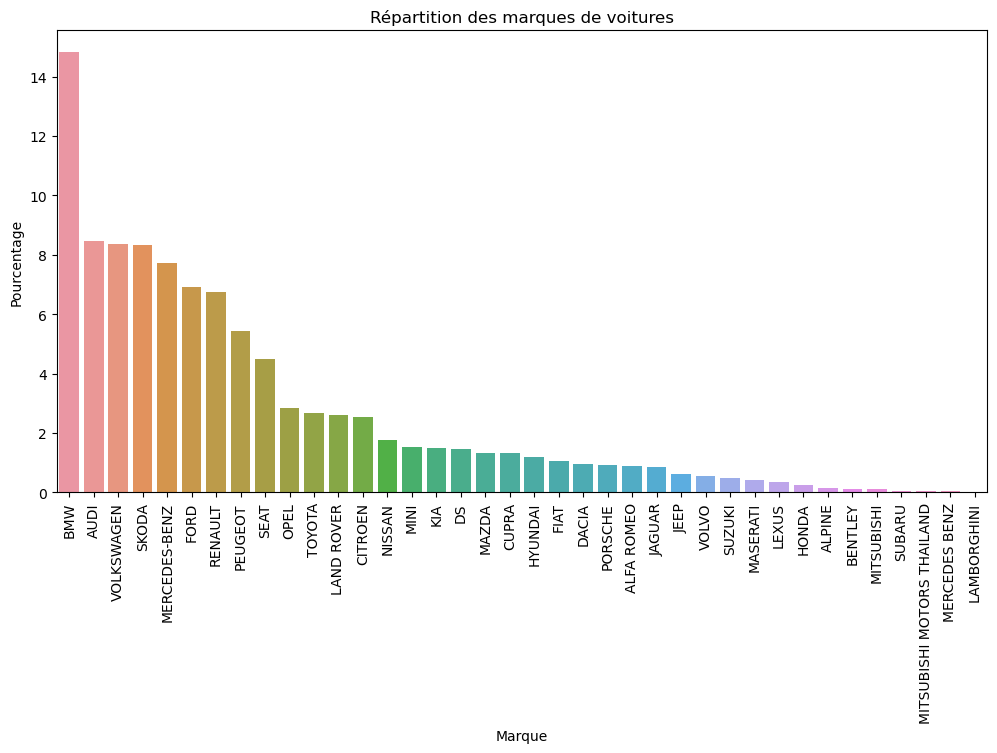

In [289]:
# Répartition des marques de voiture
brand_counts = df['Marque'].value_counts()

# Calcul du pourcentage de chaque marque
brand_percentage = (brand_counts / len(df)) * 100

# Affichage des résultats
print("Répartition des marques de voitures dans le dataset :")
print(brand_percentage)

# Visualisation sous forme de graphique à barres
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_percentage.index, y=brand_percentage.values)
plt.xticks(rotation=90)
plt.xlabel("Marque")
plt.ylabel("Pourcentage")
plt.title("Répartition des marques de voitures")
plt.show()

# <font color='#3585CD'>Faut-il garder les véhicules électriques et hydrogènes ?</font>
Notre objectif est de prédire les émissions directes de CO2. Garder les véhicules électriques et hydrogènes risque de biaiser notre modèle. Nous allons donc exclure les véhicules électriques de notre dataset

In [290]:
# Vérification des émissions de CO2 des véhicules hydrogènes
df_hydrogen = df[df["Carburant"] == "hydrogen"]
df_hydrogen['CO2'].value_counts()

Series([], Name: CO2, dtype: int64)

In [291]:
# Vérification des émissions de CO2 des véhicules hydrogènes
df_elec = df[df["Carburant"] == "electric"]
df_hydrogen['CO2'].value_counts()

Series([], Name: CO2, dtype: int64)

In [292]:
# Nous excluons les véhicules électriques et hydrogènes
df = df[(df["Carburant"] != "electric") & (df["Carburant"] != "hydrogen")]

In [293]:
df.shape

(13856, 11)

# <font color='#3585CD'>Distribution des variables catégorielles</font>

In [294]:
sorted(df['Marque'].unique())

['ALFA ROMEO',
 'ALPINE',
 'AUDI',
 'BENTLEY',
 'BMW',
 'CITROEN',
 'CUPRA',
 'DACIA',
 'DS',
 'FIAT',
 'FORD',
 'HONDA',
 'HYUNDAI',
 'JAGUAR',
 'JEEP',
 'KIA',
 'LAMBORGHINI',
 'LAND ROVER',
 'LEXUS',
 'MASERATI',
 'MAZDA',
 'MERCEDES BENZ',
 'MERCEDES-BENZ',
 'MINI',
 'MITSUBISHI',
 'MITSUBISHI MOTORS THAILAND',
 'NISSAN',
 'OPEL',
 'PEUGEOT',
 'PORSCHE',
 'RENAULT',
 'SEAT',
 'SKODA',
 'SUBARU',
 'SUZUKI',
 'TOYOTA',
 'VOLKSWAGEN',
 'VOLVO']

In [295]:
replace_mk = {'MERCEDES AMG' : 'MERCEDES BENZ',
              'MERCEDES-BENZ' : 'MERCEDES BENZ',
              'MITSUBISHI MOTORS CORPORATION' : 'MITSUBISHI',
              'MITSUBISHI MOTORS THAILAND' : 'MITSUBISHI'}
df['Marque'] = df['Marque'].replace(replace_mk)

In [296]:
df['Marque'].nunique()

36

In [297]:
def analyser_variable_categorielle_plotly(df, variable, top_n=100, display_array=True):
  """
  Analyse une variable catégorielle en affichant un DataFrame des 'top_n' catégories les plus fréquentes, ainsi qu'un graphique.

  :param df: DataFrame contenant la variable à analyser.
  :param variable: Nom de la variable catégorielle.
  :param top_n: Nombre de catégories à afficher (par défaut 100).
  """

  if display_array == True:
    top_cat = f"(Top {top_n} catégories)" if top_n != 100 else ""
    print(f"\n Analyse de la variable : {variable} {top_cat}")

  # Calcul des fréquences et pourcentages
  category_counts = df[variable].value_counts().head(top_n)
  category_percent = df[variable].value_counts(normalize=True).head(top_n) * 100

  # Création d’un DataFrame avec Libellé, Total et Pourcentage
  df_summary = pd.DataFrame({
      "Libellé": category_counts.index,
      "Total": category_counts.values,
      "Pourcentage": category_percent.values
  })

  # Affichage du tableau de synthèse
  display(df_summary)

  # Création du graphique interactif avec Plotly
  nb = top_n
  if top_n == 100:
    nb = ""
  fig = px.bar(df_summary,
                x="Libellé",
                y="Total",
                text="Total",
                title=f'Distribution des {nb} premières catégories de {variable}',
                labels={"Libellé": variable, "Total": "Nombre d'occurrences"},
                template="plotly_white")

  fig.update_traces(textposition='outside')
  fig.update_layout(xaxis_tickangle=-45)

  # Affichage du graphique
  fig.show()


### Remplacement

Certaines valeurs peuvent être regroupées :



*   'diesel/electric' & 'petrol/electric' sont des véhicules hybride
*   'lpg' & 'ng' sont des énergies alternatives


In [298]:
replace_ft = {'diesel/electric' : 'hybride',
              'petrol/electric' : 'hybride',
              'lpg' : 'gaz',
              'ng' : 'gaz'}
df['Carburant'] = df['Carburant'].replace(replace_ft)

# <font color='#3585CD'>Distribution des variables numériques</font>

In [299]:

from scipy.stats import gaussian_kde
def analyser_variables_numeriques_plotly(df, variables, bins=30):
    """
    Analyse les variables numériques en affichant un histogramme + KDE (distribution) et un boxplot interactifs.

    :param df: DataFrame contenant les données.
    :param variables: Liste des variables numériques à analyser.
    :param bins: Nombre de bins pour l'histogramme (par défaut 30).
    """
    for var in variables:
        #print(f"\n Analyse de la variable : {var}")
        #display(df[var].describe())  # Affichage des statistiques descriptives

        # Supprimer les valeurs NaN
        data = df[var].dropna()

        # Histogramme
        hist = go.Histogram(
            x=data,
            nbinsx=bins,
            marker=dict(color='skyblue', line=dict(color='black', width=1)),  # Bordures noires
            opacity=0.6,  # Semi-transparent pour voir la KDE
            name="Histogramme"
        )

        # Calcul des densités pour la courbe KDE
        kde = gaussian_kde(data)
        x_vals = np.linspace(data.min(), data.max(), 500)  # Intervalle lissé
        kde_vals = kde(x_vals)

        # Courbe KDE
        kde_curve = go.Scatter(
            x=x_vals,
            y=kde_vals * len(data) * (data.max() - data.min()) / bins,  # Mise à l'échelle par rapport à l'histogramme
            mode='lines',
            line=dict(color='blue', width=2),
            name="Densité (KDE)"
        )

        # Création de la figure combinée
        fig = go.Figure(data=[hist, kde_curve])

        # Mise en page
        fig.update_layout(
            title=f'Distribution de {var} (Histogramme + KDE)',
            xaxis_title="Valeur",
            yaxis_title="Fréquence",
            template="plotly_white",
            barmode='overlay'
        )

        # Affichage du graphique combiné
        fig.show()

        # Création du boxplot
        boxplot = go.Box(
            x=data,
            marker=dict(color='salmon'),
            name="Boxplot",
            boxpoints="outliers"  # Affichage des outliers
        )

        # Création et affichage du Boxplot
        fig_box = go.Figure(data=[boxplot])
        fig_box.update_layout(
            title=f'Boxplot de {var}',
            xaxis_title="Valeur",
            template="plotly_white"
        )

        fig_box.show()


In [300]:
# Sélection des colonnes numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_vars

['Masse à vide',
 'CO2',
 'Cylindrée moteur',
 'Puissance moteur',
 'impact_innovaion',
 'Consommation carburant']

In [301]:
df.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,type_innovation,impact_innovaion,Consommation carburant,type_innovation_encod
ID,,,,,,,,,,,
122083623,PEUGEOT,208,-0.849792,107,diesel,0.477030,-0.420959,e2 28 29,1.87,4.1,20
122083625,VOLKSWAGEN,T-ROC,0.093760,139,petrol,0.474064,0.935288,e13 29,1.17,6.2,11
122083626,RENAULT,CAPTUR,0.167093,136,petrol,-0.018369,1.167788,e2 33 37,2.11,6.0,26
122083627,VOLKSWAGEN,POLO,-0.698237,126,petrol,-1.006202,-0.614709,e1 29,1.14,5.5,5
122083628,SUZUKI,VITARA,-0.092017,119,petrol,0.367271,-0.420959,e6 37,0.78,5.3,70


In [302]:
df.shape

(13856, 11)

In [303]:
df = df.drop_duplicates().reset_index(drop=True)

# <font color='#3585CD'>Test de corrélation de Pearson</font>

In [304]:
## Les hypothèses :
# H0 : Les variables tension et âge ne sont pas corrélées
# H1 : Les deux variables sont corrélées 

## Le test : 
from scipy.stats import pearsonr
pearsonr(x = df["CO2"], y = df["Masse à vide"]) 

print("p-value: ", pearsonr(x = df["CO2"], y = df["Masse à vide"])[1])
print("coefficient: ", pearsonr(x = df["CO2"], y = df["Masse à vide"])[0])

# la p-valeur est très petite < 0.05, on rejette H0 et on conclut H1 
# c'est-à-dire qu'il y a une corrélation entre les variables tension et âge. 

# une p-valeur < α, indique une corrélation statistiquement significatitive entre les 
# variables x et y. Le coefficient nous permet de voir l'intensité de la corrélation.


p-value:  0.0
coefficient:  0.7772818674052933


In [305]:
## Les hypothèses :
# H0 : Les variables tension et âge ne sont pas corrélées
# H1 : Les deux variables sont corrélées 

## Le test : 
from scipy.stats import pearsonr
pearsonr(x = df["CO2"], y = df["Cylindrée moteur"]) 

print("p-value: ", pearsonr(x = df["CO2"], y = df["Cylindrée moteur"])[1])
print("coefficient: ", pearsonr(x = df["CO2"], y = df["Cylindrée moteur"])[0])

# la p-valeur est très petite < 0.05, on rejette H0 et on conclut H1 
# c'est-à-dire qu'il y a une corrélation entre les variables tension et âge. 

# une p-valeur < α, indique une corrélation statistiquement significatitive entre les 
# variables x et y. Le coefficient nous permet de voir l'intensité de la corrélation.

p-value:  0.0
coefficient:  0.6620921793378403


In [306]:
## Les hypothèses :
# H0 : Les variables tension et âge ne sont pas corrélées
# H1 : Les deux variables sont corrélées 

## Le test : 
from scipy.stats import pearsonr
pearsonr(x = df["CO2"], y = df["Puissance moteur"]) 

print("p-value: ", pearsonr(x = df["CO2"], y = df["Puissance moteur"])[1])
print("coefficient: ", pearsonr(x = df["CO2"], y = df["Puissance moteur"])[0])

# la p-valeur est très petite < 0.05, on rejette H0 et on conclut H1 
# c'est-à-dire qu'il y a une corrélation entre les variables tension et âge. 

# une p-valeur < α, indique une corrélation statistiquement significatitive entre les 
# variables x et y. Le coefficient nous permet de voir l'intensité de la corrélation.

p-value:  0.0
coefficient:  0.748670606174218


In [307]:
## Les hypothèses :
# H0 : Les variables tension et âge ne sont pas corrélées
# H1 : Les deux variables sont corrélées 

## Le test : 
from scipy.stats import pearsonr
pearsonr(x = df["CO2"], y = df["Consommation carburant"]) 

print("p-value: ", pearsonr(x = df["CO2"], y = df["Consommation carburant"])[1])
print("coefficient: ", pearsonr(x = df["CO2"], y = df["Consommation carburant"])[0])

# la p-valeur est très petite < 0.05, on rejette H0 et on conclut H1 
# c'est-à-dire qu'il y a une corrélation entre les variables tension et âge. 

# une p-valeur < α, indique une corrélation statistiquement significatitive entre les 
# variables x et y. Le coefficient nous permet de voir l'intensité de la corrélation.

p-value:  0.0
coefficient:  0.9315291436982428


# <font color='#3585CD'>Test ANOVA</font>

In [308]:
# Sélection des colonnes non numériques
char_vars = df.select_dtypes(exclude=['number']).columns.tolist()
char_vars

['Marque', 'Modèle', 'Carburant', 'type_innovation']

In [309]:
## Les modalités de douleur_thor :
print("Les différentes modalités sont :", df["Marque"].unique())

## Les hypothèses :
print("Les hypothèses : ")
print("H0 : Il n'y a pas d'influence significative")
print("H1 : Il y a une influence significative")


Les différentes modalités sont : ['PEUGEOT' 'VOLKSWAGEN' 'RENAULT' 'SUZUKI' 'DACIA' 'MINI' 'TOYOTA'
 'CITROEN' 'ALFA ROMEO' 'MERCEDES BENZ' 'OPEL' 'AUDI' 'HYUNDAI' 'KIA'
 'FORD' 'BMW' 'VOLVO' 'ALPINE' 'SEAT' 'CUPRA' 'JEEP' 'DS' 'NISSAN' 'FIAT'
 'SKODA' 'MAZDA' 'HONDA' 'MITSUBISHI' 'JAGUAR' 'PORSCHE' 'LAND ROVER'
 'LEXUS' 'BENTLEY' 'MASERATI' 'LAMBORGHINI' 'SUBARU']
Les hypothèses : 
H0 : Il n'y a pas d'influence significative
H1 : Il y a une influence significative


In [310]:
##  Le test ANOVA :
import statsmodels.api 
result = statsmodels.formula.api.ols('CO2 ~ Marque', data=df).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

## La conclusion :
print("Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1")
# on conclut donc a une influence significative du type de la douleur sur la fréquence maximale


,df,sum_sq,mean_sq,F,PR(>F)
Marque,35.0,5.934238e+06,169549.668241,309.958776,0.0
Residual,13820.0,7.559639e+06,547.007156,NaN,NaN


Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1


In [311]:
## Les modalités de douleur_thor :
print("Les différentes modalités sont :", df["Carburant"].unique())

## Les hypothèses :
print("Les hypothèses : ")
print("H0 : Il n'y a pas d'influence significative")
print("H1 : Il y a une influence significative")

Les différentes modalités sont : ['diesel' 'petrol' 'gaz' 'e85']
Les hypothèses : 
H0 : Il n'y a pas d'influence significative
H1 : Il y a une influence significative


In [312]:
##  Le test ANOVA :
import statsmodels.api 
result = statsmodels.formula.api.ols('CO2 ~ Carburant', data=df).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

## La conclusion :
print("Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1")
# on conclut donc a une influence significative du type de la douleur sur la fréquence maximale

,df,sum_sq,mean_sq,F,PR(>F)
Carburant,3.0,3.331972e+05,111065.731959,116.899925,9.221274e-75
Residual,13852.0,1.316068e+07,950.092411,NaN,NaN


Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1


In [313]:
## Les modalités de douleur_thor :
print("Les différentes modalités sont :", df["type_innovation"].unique())

## Les hypothèses :
print("Les hypothèses : ")
print("H0 : Il n'y a pas d'influence significative")
print("H1 : Il y a une influence significative")

Les différentes modalités sont : ['e2 28 29' 'e13 29' 'e2 33 37' 'e1 29' 'e6 37' 'e2 29 37' 'e2 37'
 'e19 29 37' 'e24 28 29' 'e9 29 37' 'e13 29 37' 'e3 32 37' 'e5 28' 'e5 29'
 'e13 32 37' 'e1 29 37' 'e5 32' 'e2 28' 'e4 33 37' 'e2 29' 'e9 29' 'e9 37'
 'e3 37 32' 'e3 29' 'e24 32' 'e8 29 37' 'e13 28 29' 'e13 37' 'e24 29 37'
 'e9 32 37' 'e6 28' 'e3 33' 'e2 29 28' 'e3 29 37' 'e4 37' 'e5 37'
 'e5 37 e9 32' 'e5 32 37' 'e13 33 37' 'e4 32 e4 37' 'e24 37' 'e4 32 37'
 'e5 37 e5 32' 'e13 28' 'e24 32 37' 'e24 29' 'e4 28' 'e3 32' 'e9 29 e9 28'
 'e9 33 37' 'e5 28 e9 32' 'e8 37' 'e2 33' 'e1 28 29' 'e9 3732'
 'e5 32 e4 37' 'e9 32' 'e13 33' 'e1 33' 'e2 37 29' 'e24 28' 'e9 28 29'
 'e9 33' 'e3 28 32 37' 'e4 29 e4 37' 'e3 28 29' 'e2 28 33' 'e5 37 e5 29'
 'e3 37' 'e3 28' 'e5 28 29' 'e11 29' 'e8 29' 'e4 29 28' 'e8 29 28' '0'
 'e1 08 33' 'e1 08 29' 'e1 02 29' 'e6 2928' 'e6 29 28' 'e4 28 29'
 'e8 28 29' 'e5 29 37' 'e9 28' 'e19 28 29' 'e3 29 28']
Les hypothèses : 
H0 : Il n'y a pas d'influence significative
H1 

In [314]:
##  Le test ANOVA :
import statsmodels.api 
result = statsmodels.formula.api.ols('CO2 ~ type_innovation', data=df).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

## La conclusion :
print("Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1")
# on conclut donc a une influence significative du type de la douleur sur la fréquence maximale

,df,sum_sq,mean_sq,F,PR(>F)
type_innovation,86.0,5.722541e+06,66541.175834,117.895486,0.0
Residual,13769.0,7.771336e+06,564.408175,NaN,NaN


Conclusion : La p-value (PR(>F)) est inférieure à 5% donc on rejette H0 et on conclut H1
